In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


'Adsız klasör'	 archive3.zip   archive.zip  'Colab Notebooks'	 madrid_data


In [ ]:
!unzip "/content/drive/MyDrive/archive3.zip" -d "/content/drive/MyDrive/madrid_data"


Archive:  /content/drive/MyDrive/archive3.zip
replace /content/drive/MyDrive/madrid_data/Madrid Daily Weather 1997-2015.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!ls /content/drive/MyDrive/madrid_data


'Madrid Daily Weather 1997-2015.csv'


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/madrid_data/Madrid Daily Weather 1997-2015.csv"
)

df.head()


,CET,Max TemperatureC,Mean TemperatureC,Min TemperatureC,Dew PointC,MeanDew PointC,Min DewpointC,Max Humidity,Mean Humidity,Min Humidity,...,Max VisibilityKm,Mean VisibilityKm,Min VisibilitykM,Max Wind SpeedKm/h,Mean Wind SpeedKm/h,Max Gust SpeedKm/h,Precipitationmm,CloudCover,Events,WindDirDegrees
0,1997-01-01,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,...,10.0,9.0,4.0,13,6,NaN,0.0,6.0,NaN,229
1,1997-01-02,7.0,3.0,0.0,6.0,3.0,0.0,100.0,92.0,71.0,...,10.0,9.0,4.0,26,8,47.0,0.0,5.0,Rain,143
2,1997-01-03,5.0,3.0,2.0,5.0,1.0,-1.0,100.0,85.0,70.0,...,10.0,10.0,7.0,27,19,NaN,0.0,6.0,Rain-Snow,256
3,1997-01-04,7.0,3.0,-1.0,-2.0,-3.0,-4.0,86.0,63.0,49.0,...,10.0,10.0,10.0,27,19,40.0,0.0,2.0,NaN,284
4,1997-01-05,2.0,0.0,-1.0,2.0,0.0,-3.0,100.0,95.0,86.0,...,10.0,5.0,1.0,14,6,NaN,0.0,7.0,Snow,2


In [ ]:
!pip -q install lightgbm


In [ ]:
!pip -q install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [ ]:
# 1) Kolon adlarını temizle (baş/son boşluk varsa)
df.columns = df.columns.str.strip()

# 2) Tarihi datetime yap
df["CET"] = pd.to_datetime(df["CET"], errors="coerce")

# 3) Hedef ve önemli sütunları numeric'e çevir
num_cols = [
    "Mean TemperatureC",
    "Precipitationmm",
    "Max TemperatureC",
    "Min TemperatureC",
    "Mean Humidity",
    "MeanDew PointC"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 4) Hedeflerde NaN varsa sil
df = df.dropna(subset=["Mean TemperatureC", "Precipitationmm"]).reset_index(drop=True)

print("Temizlik sonrası veri şekli:", df.shape)
print(df.isna().sum().sort_values(ascending=False).head(10))



Temizlik sonrası veri şekli: (6809, 23)
Events                5011
Max Gust SpeedKm/h    3303
CloudCover            1369
Max VisibilityKm       937
Min VisibilitykM       937
Mean VisibilityKm      937
CET                      0
Min DewpointC            0
MeanDew PointC           0
Dew PointC               0
dtype: int64


In [ ]:
# ============================
# ADIM 3: SICAKLIK HEDEFİ
# ============================

TARGET = "Mean TemperatureC"

DROP_COLS = [
    "CET",
    "Mean TemperatureC",
    "Precipitationmm",
    "Events",
    "Max TemperatureC",
    "Min TemperatureC"
]

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()


X shape: (6809, 17)
y shape: (6809,)


,Dew PointC,MeanDew PointC,Min DewpointC,Max Humidity,Mean Humidity,Min Humidity,Max Sea Level PressurehPa,Mean Sea Level PressurehPa,Min Sea Level PressurehPa,Max VisibilityKm,Mean VisibilityKm,Min VisibilitykM,Max Wind SpeedKm/h,Mean Wind SpeedKm/h,Max Gust SpeedKm/h,CloudCover,WindDirDegrees
0,5.0,3.0,2.0,100.0,95.0,76.0,1010,1008,1004,10.0,9.0,4.0,13,6,NaN,6.0,229
1,6.0,3.0,0.0,100.0,92.0,71.0,1007,1003,997,10.0,9.0,4.0,26,8,47.0,5.0,143
2,5.0,1.0,-1.0,100.0,85.0,70.0,1005,999,996,10.0,10.0,7.0,27,19,NaN,6.0,256
3,-2.0,-3.0,-4.0,86.0,63.0,49.0,1012,1010,1005,10.0,10.0,10.0,27,19,40.0,2.0,284
4,2.0,0.0,-3.0,100.0,95.0,86.0,1012,1008,1005,10.0,5.0,1.0,14,6,NaN,7.0,2


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)




Train: (5447, 17) (5447,)
Test : (1362, 17) (1362,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=7),
    "SVM (RBF)": SVR(kernel="rbf"),
    "Decision Tree": DecisionTreeRegressor(max_depth=15, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "YSA (MLP)": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=300,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

}



In [ ]:
from sklearn.impute import SimpleImputer

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # 🔴 ÖNEMLİ EKLEME
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 5447, number of used features: 17
[LightGBM] [Info] Start training from score 14.646594


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,R2,MAE,RMSE
7,CatBoost,0.990801,0.573978,0.730963
6,LightGBM,0.989913,0.599029,0.765444
5,YSA (MLP),0.989742,0.605491,0.771905
4,Random Forest,0.987480,0.659430,0.852783
2,SVM (RBF),0.979696,0.773819,1.085977
0,Linear Regression,0.973725,0.960131,1.235394
3,Decision Tree,0.969855,0.947726,1.323239
1,KNN,0.951032,1.284351,1.686515


In [ ]:
print(X_train.dtypes)


Dew PointC                    float64
MeanDew PointC                float64
Min DewpointC                 float64
Max Humidity                  float64
Mean Humidity                 float64
Min Humidity                  float64
Max Sea Level PressurehPa       int64
Mean Sea Level PressurehPa      int64
Min Sea Level PressurehPa       int64
Max VisibilityKm              float64
Mean VisibilityKm             float64
Min VisibilitykM              float64
Max Wind SpeedKm/h              int64
Mean Wind SpeedKm/h             int64
Max Gust SpeedKm/h            float64
CloudCover                    float64
WindDirDegrees                  int64
dtype: object


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 5447, number of used features: 17
[LightGBM] [Info] Start training from score 14.646594


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


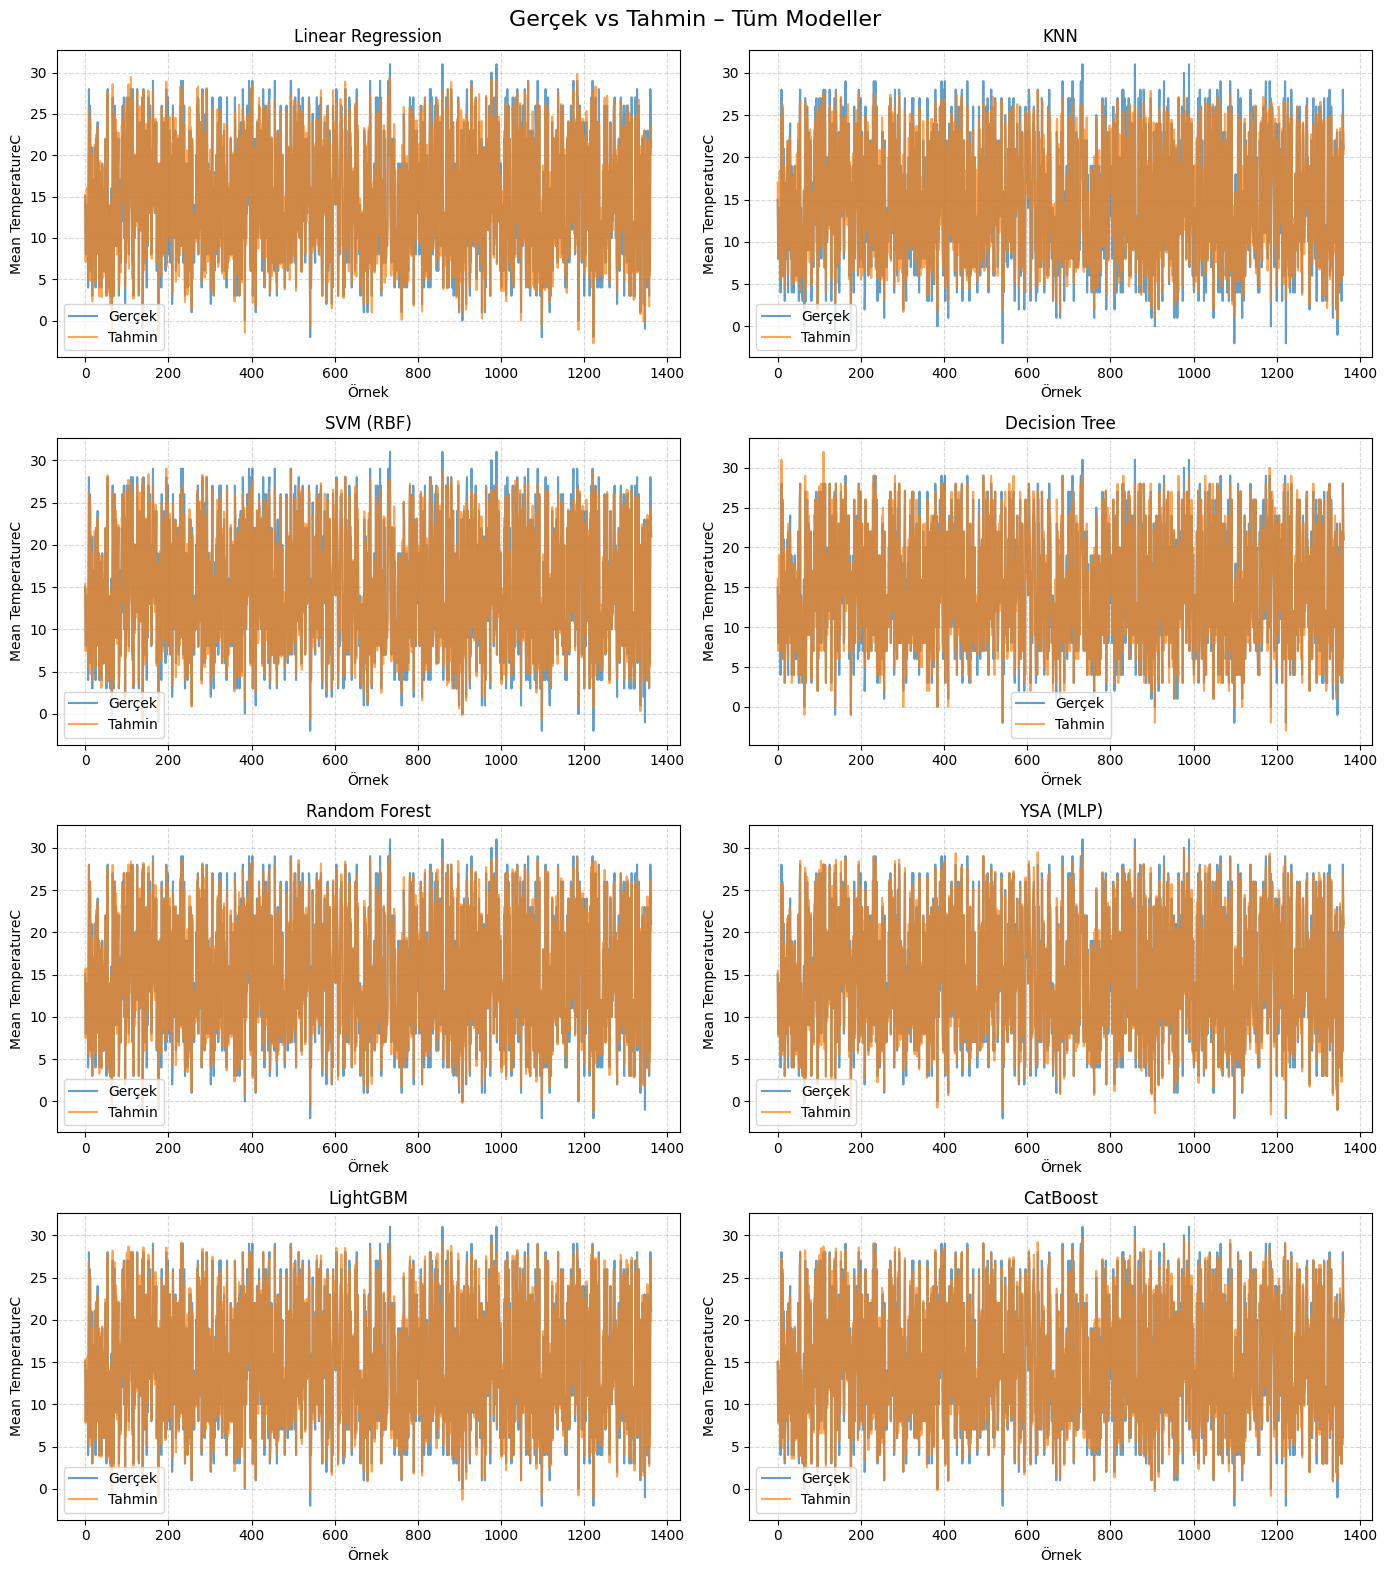

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

predictions = {}

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    predictions[name] = pipe.predict(X_test)

# Grafik
n_models = len(predictions)
n_cols = 2
n_rows = (n_models + 1) // 2

plt.figure(figsize=(14, 4*n_rows))

for i, (name, y_pred) in enumerate(predictions.items(), 1):
    plt.subplot(n_rows, n_cols, i)
    plt.plot(y_test.values, label="Gerçek", alpha=0.7)
    plt.plot(y_pred, label="Tahmin", alpha=0.7)
    plt.title(name)
    plt.xlabel("Örnek")
    plt.ylabel("Mean TemperatureC")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Gerçek vs Tahmin – Tüm Modeller", fontsize=16)
plt.tight_layout()
plt.show()



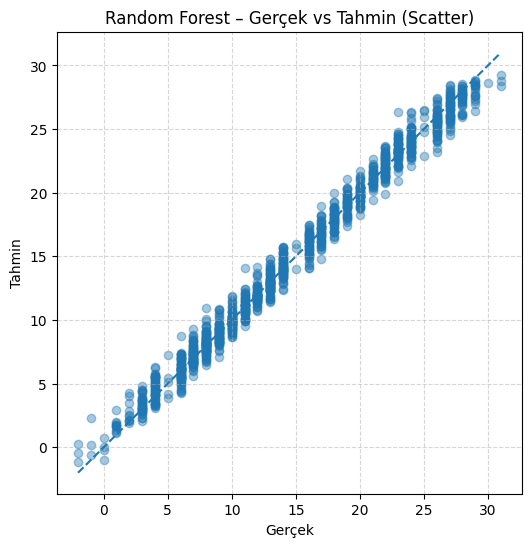

In [ ]:
best_pred = predictions["Random Forest"]

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Gerçek")
plt.ylabel("Tahmin")
plt.title("Random Forest – Gerçek vs Tahmin (Scatter)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


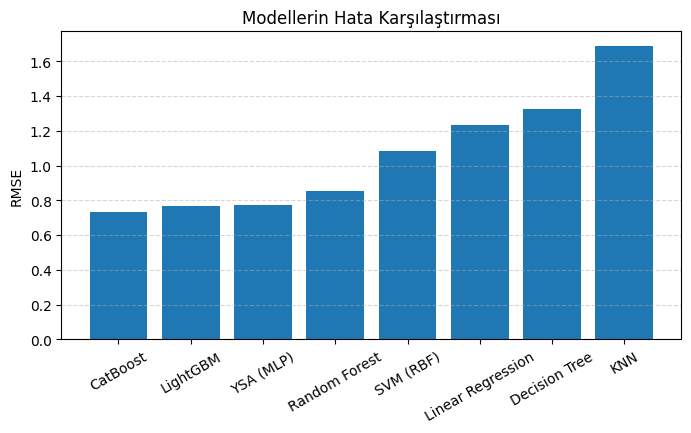

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Modellerin Hata Karşılaştırması")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()



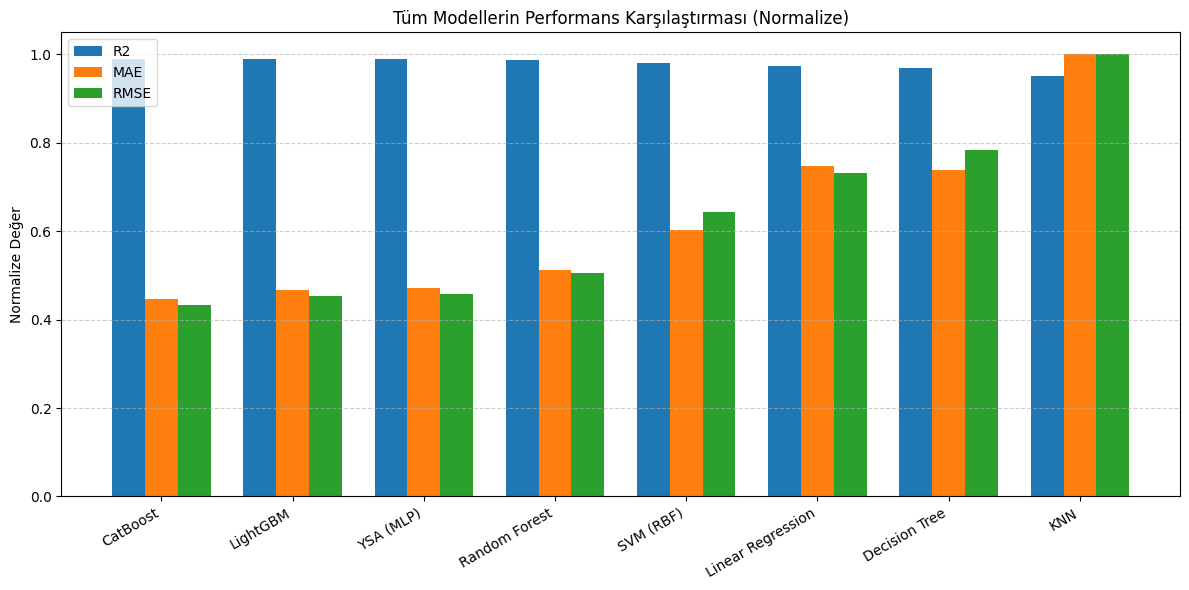

In [ ]:
results_norm = results_df.copy()

results_norm["MAE"]  = results_norm["MAE"]  / results_norm["MAE"].max()
results_norm["RMSE"] = results_norm["RMSE"] / results_norm["RMSE"].max()

metrics = ["R2", "MAE", "RMSE"]
x = np.arange(len(results_norm["Model"]))
width = 0.25

plt.figure(figsize=(12,6))
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_norm[metric], width=width, label=metric)

plt.xticks(x + width, results_norm["Model"], rotation=30, ha="right")
plt.ylabel("Normalize Değer")
plt.title("Tüm Modellerin Performans Karşılaştırması (Normalize)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2260193322.py:41: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


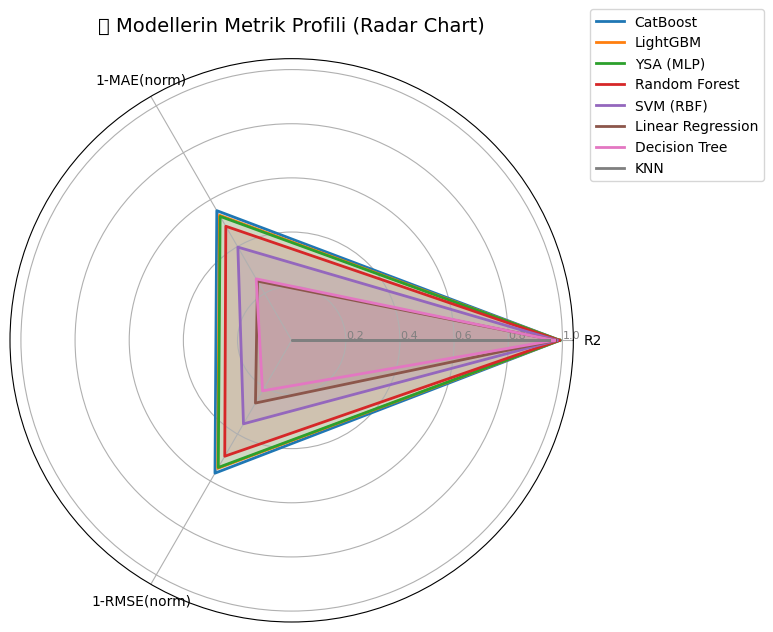

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# results_df içinde şu kolonlar olmalı: Model, R2, MAE, RMSE
assert all(c in results_df.columns for c in ["Model","R2","MAE","RMSE"]), "results_df kolonları eksik!"

# Normalize yardımcıları
mae_max  = results_df["MAE"].max()
rmse_max = results_df["RMSE"].max()

metrics = ["R2", "MAE", "RMSE"]
N = len(metrics)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for _, row in results_df.iterrows():
    r2 = row["R2"]
    mae = row["MAE"]
    rmse = row["RMSE"]

    # MAE/RMSE küçük olunca iyi → ters normalize (0..1)
    mae_score  = 1 - (mae / mae_max) if mae_max > 0 else 1.0
    rmse_score = 1 - (rmse / rmse_max) if rmse_max > 0 else 1.0

    values = [r2, mae_score, rmse_score]
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

plt.xticks(angles[:-1], ["R2", "1-MAE(norm)", "1-RMSE(norm)"])
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2","0.4","0.6","0.8","1.0"], color="gray", size=8)
plt.title("🕸️ Modellerin Metrik Profili (Radar Chart)", size=14, pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()



✅ En iyi model: CatBoost


/tmp/ipython-input-1170375928.py:47: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


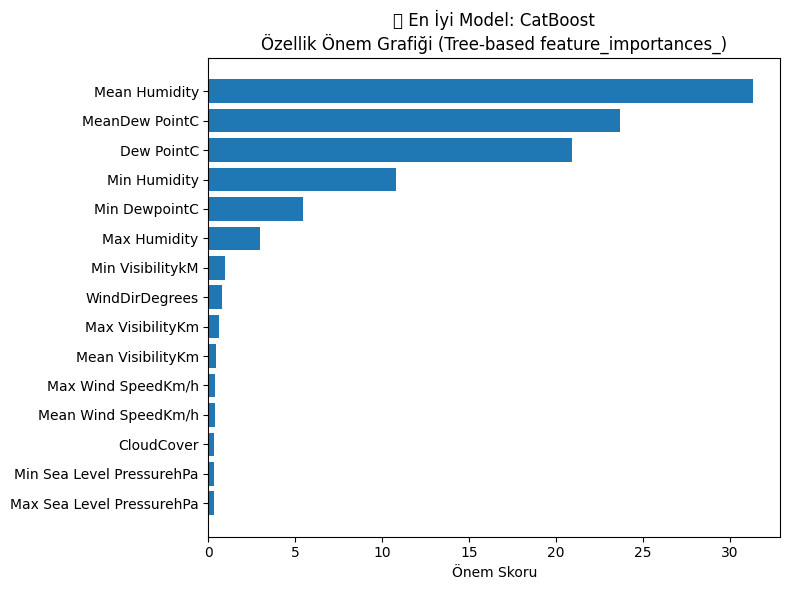

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# En iyi modeli R² değerine göre seç
best_model_name = results_df.iloc[0]["Model"]
print("✅ En iyi model:", best_model_name)

best_model = models[best_model_name]

# Bizim kullandığımız preprocessing: imputer + scaler
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", best_model)
])

pipe.fit(X_train, y_train)

# Özellik isimleri (şu an hepsi sayısal)
feature_names = X.columns.to_list()

# Önem hesapla
if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_
    method_used = "Tree-based feature_importances_"
else:
    print("Ağaç tabanlı değil → Permutation importance hesaplanıyor...")
    result = permutation_importance(pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    importance = result.importances_mean
    method_used = "Permutation importance"

# En önemli 15
top_k = 15
sorted_idx = np.argsort(importance)[::-1][:top_k]
top_features = np.array(feature_names)[sorted_idx]
top_importance = importance[sorted_idx]

# Çiz
plt.figure(figsize=(8,6))
plt.barh(top_features[::-1], top_importance[::-1])
plt.xlabel("Önem Skoru")
plt.title(f"🔹 En İyi Model: {best_model_name}\nÖzellik Önem Grafiği ({method_used})")
plt.tight_layout()
plt.show()


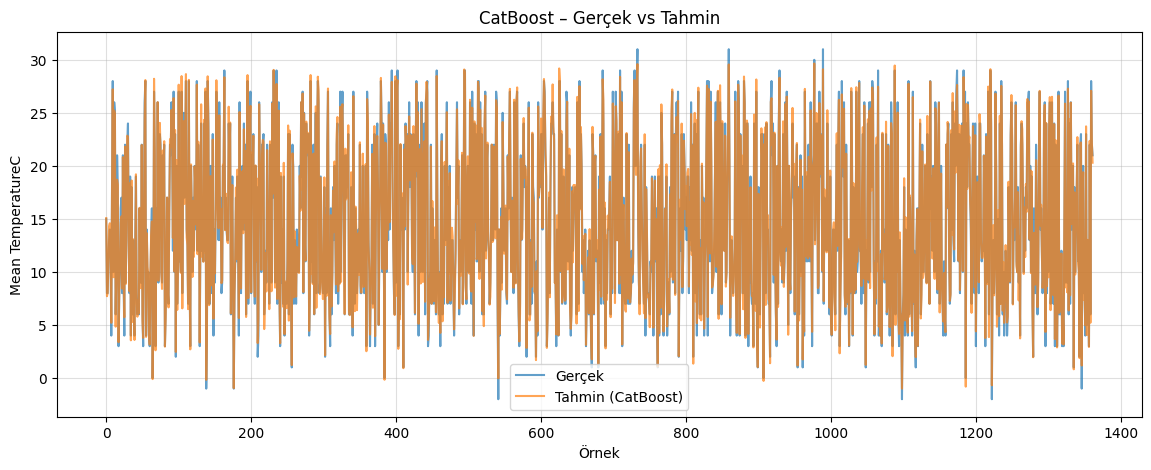

In [ ]:
best_name = "CatBoost"
best_pred = predictions[best_name]

plt.figure(figsize=(14,5))
plt.plot(y_test.values, label="Gerçek", alpha=0.7)
plt.plot(best_pred, label="Tahmin (CatBoost)", alpha=0.7)
plt.title("CatBoost – Gerçek vs Tahmin")
plt.xlabel("Örnek")
plt.ylabel("Mean TemperatureC")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


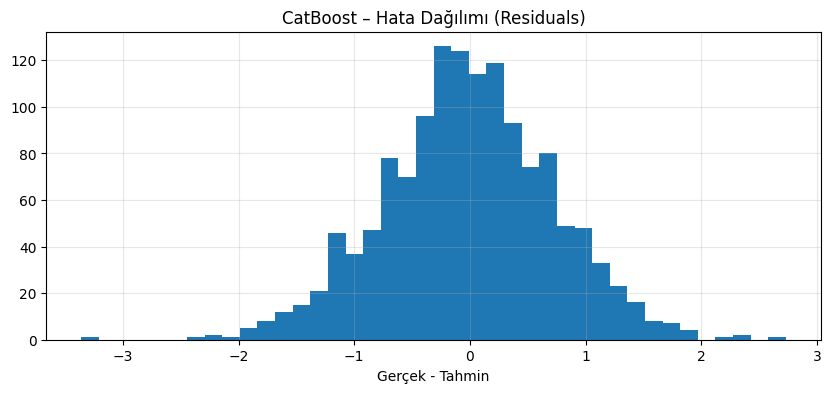

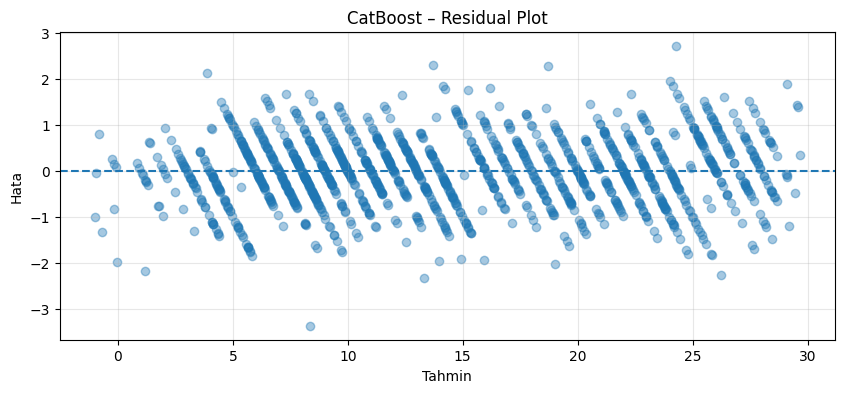

In [ ]:
res = y_test.values - best_pred

plt.figure(figsize=(10,4))
plt.hist(res, bins=40)
plt.title("CatBoost – Hata Dağılımı (Residuals)")
plt.xlabel("Gerçek - Tahmin")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.scatter(best_pred, res, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title("CatBoost – Residual Plot")
plt.xlabel("Tahmin")
plt.ylabel("Hata")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", models["CatBoost"])
])
cat_pipe.fit(X_train, y_train)

cb_model = cat_pipe.named_steps["model"]

import pandas as pd
fi = pd.Series(cb_model.get_feature_importance(), index=X_train.columns).sort_values(ascending=False)

fi.head(15)


,0
Mean Humidity,31.321802
MeanDew PointC,23.654353
Dew PointC,20.927375
Min Humidity,10.788428
Min DewpointC,5.427705
Max Humidity,2.962756
Min VisibilitykM,0.946392
WindDirDegrees,0.755004
Max VisibilityKm,0.590020
Mean VisibilityKm,0.440522


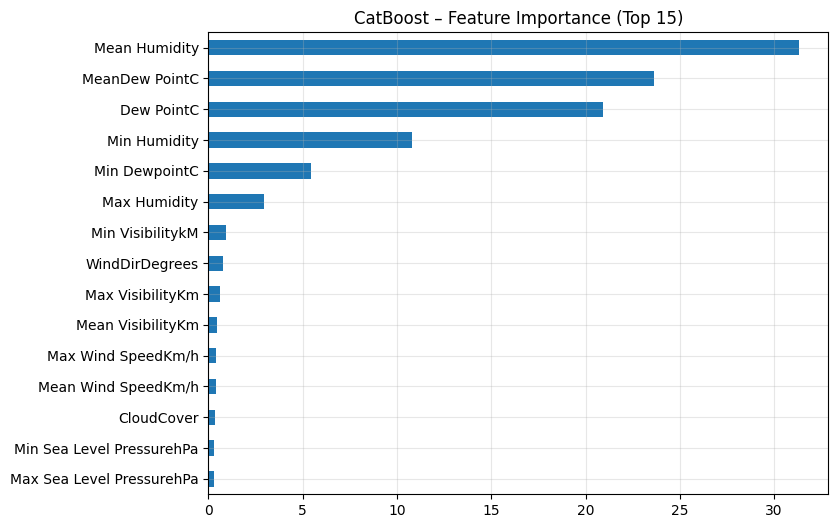

In [ ]:
import matplotlib.pyplot as plt

top = fi.head(15).sort_values()
plt.figure(figsize=(8,6))
top.plot(kind="barh")
plt.title("CatBoost – Feature Importance (Top 15)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)


In [ ]:
cat_evals = cat_model.get_evals_result()

cat_train_loss = cat_evals["learn"]["RMSE"]
cat_val_loss   = cat_evals["validation"]["RMSE"]


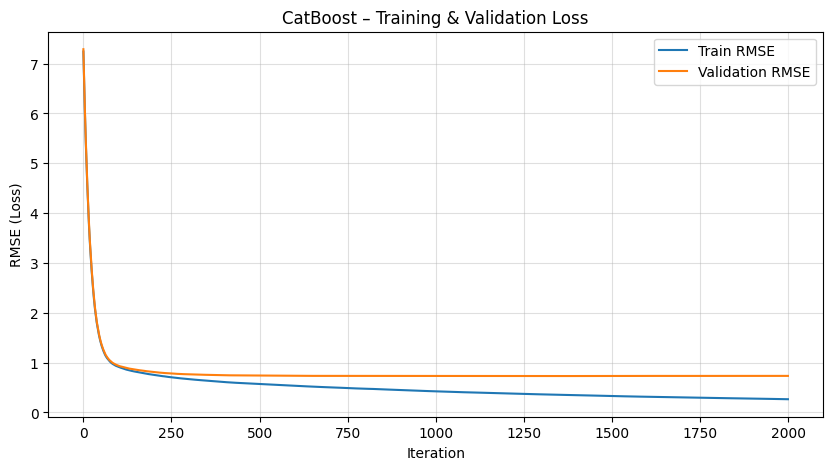

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cat_train_loss, label="Train RMSE")
plt.plot(cat_val_loss, label="Validation RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE (Loss)")
plt.title("CatBoost – Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric="rmse"
)



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 885
[LightGBM] [Info] Number of data points in the train set: 5447, number of used features: 17
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 14.646594


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=2000,
              random_state=42, subsample=0.8)

In [ ]:
lgbm_evals = lgbm_model.evals_result_

lgbm_train_loss = lgbm_evals["training"]["rmse"]
lgbm_val_loss   = lgbm_evals["valid_1"]["rmse"]


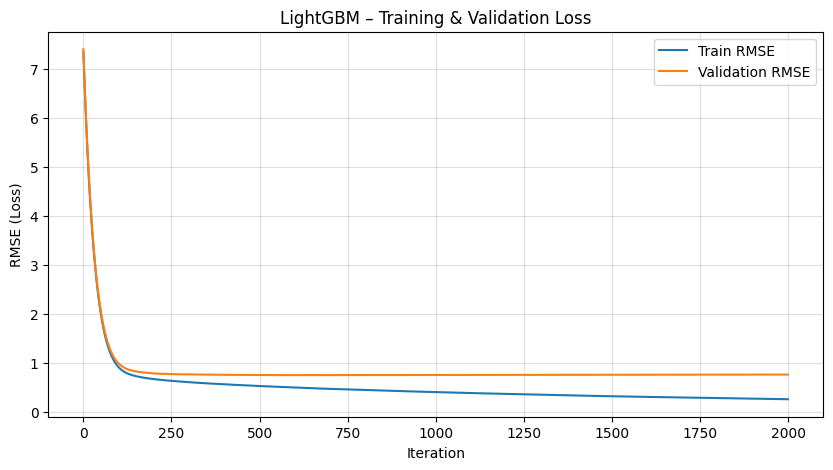

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(lgbm_train_loss, label="Train RMSE")
plt.plot(lgbm_val_loss, label="Validation RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE (Loss)")
plt.title("LightGBM – Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()


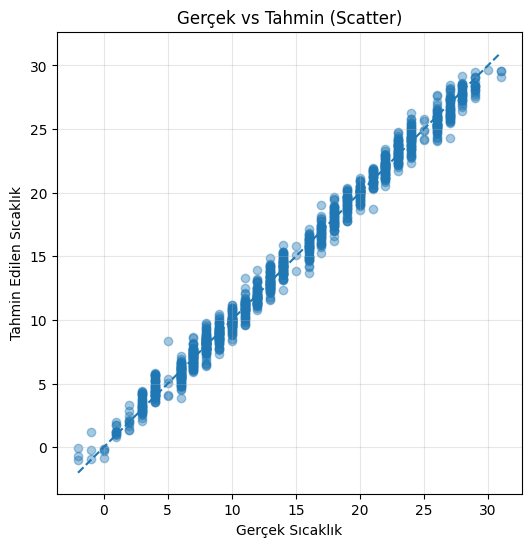

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Gerçek Sıcaklık")
plt.ylabel("Tahmin Edilen Sıcaklık")
plt.title("Gerçek vs Tahmin (Scatter)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
df.columns


Index(['CET', 'Max TemperatureC', 'Mean TemperatureC', 'Min TemperatureC',
       'Dew PointC', 'MeanDew PointC', 'Min DewpointC', 'Max Humidity',
       'Mean Humidity', 'Min Humidity', 'Max Sea Level PressurehPa',
       'Mean Sea Level PressurehPa', 'Min Sea Level PressurehPa',
       'Max VisibilityKm', 'Mean VisibilityKm', 'Min VisibilitykM',
       'Max Wind SpeedKm/h', 'Mean Wind SpeedKm/h', 'Max Gust SpeedKm/h',
       'Precipitationmm', 'CloudCover', 'Events', 'WindDirDegrees'],
      dtype='object')

In [ ]:
import pandas as pd

df["CET"] = pd.to_datetime(df["CET"], errors="coerce")
df["year"] = df["CET"].dt.year

train = df[df["year"] < 2014].copy()
test  = df[df["year"] >= 2014].copy()

print("Train:", train.shape, "Test:", test.shape)


Train: (6079, 24) Test: (730, 24)


In [ ]:
TARGET = "Mean TemperatureC"

X_test2 = test.drop(columns=[TARGET, "CET"])
y_test2 = test[TARGET]


In [ ]:
TARGET = "Mean TemperatureC"

df["CET"] = pd.to_datetime(df["CET"], errors="coerce")
df["year"] = df["CET"].dt.year

train = df[df["year"] < 2014].copy()
test  = df[df["year"] >= 2014].copy()

FEATURES = [c for c in df.columns if c not in [TARGET, "CET", "Events"]]  # 👈 Events çıkarıldı

X_train2 = train[FEATURES]
y_train2 = train[TARGET]
X_test2  = test[FEATURES]
y_test2  = test[TARGET]

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

best_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", models["CatBoost"])
])

best_pipe.fit(X_train2, y_train2)
best_pred2 = best_pipe.predict(X_test2)

print("Uzunluklar:", len(best_pred2), len(test))


Uzunluklar: 730 730


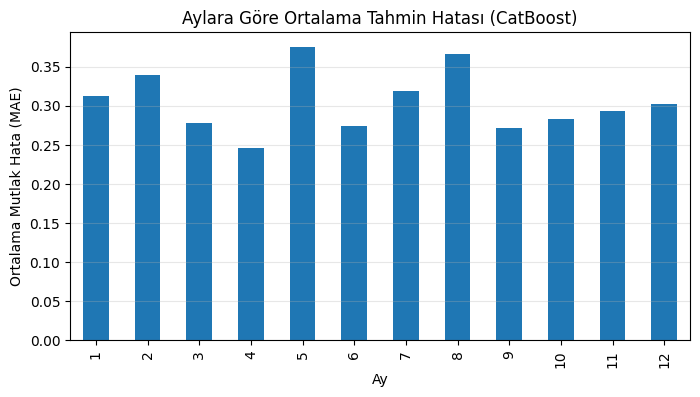

In [ ]:
import matplotlib.pyplot as plt

test_df = test.copy()
test_df["pred"] = best_pred2
test_df["abs_error"] = (test_df[TARGET] - test_df["pred"]).abs()
test_df["month"] = test_df["CET"].dt.month

monthly_error = test_df.groupby("month")["abs_error"].mean()

plt.figure(figsize=(8,4))
monthly_error.plot(kind="bar")
plt.xlabel("Ay")
plt.ylabel("Ortalama Mutlak Hata (MAE)")
plt.title("Aylara Göre Ortalama Tahmin Hatası (CatBoost)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cb = models["CatBoost"]
lgbm = models["LightGBM"]

cb.fit(X_train2, y_train2)
pred_cb = cb.predict(X_test2)

lgbm.fit(X_train2, y_train2, eval_set=[(X_test2, y_test2)], eval_metric="rmse")
pred_lgbm = lgbm.predict(X_test2)

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results_2 = pd.DataFrame([
    {"Model": "CatBoost", **metrics(y_test2, pred_cb)},
    {"Model": "LightGBM", **metrics(y_test2, pred_lgbm)},
]).sort_values("RMSE")

results_2


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 997
[LightGBM] [Info] Number of data points in the train set: 6079, number of used features: 21
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 14.520974


,Model,MAE,RMSE,R2
0,CatBoost,0.295538,0.377915,0.997393
1,LightGBM,0.321768,0.404615,0.997012


In [ ]:
tol = 1.0  # ±1°C
acc_cb = (abs(y_test2.values - pred_cb) <= tol).mean()
acc_lgbm = (abs(y_test2.values - pred_lgbm) <= tol).mean()

acc_cb, acc_lgbm


(np.float64(0.9917808219178083), np.float64(0.989041095890411))

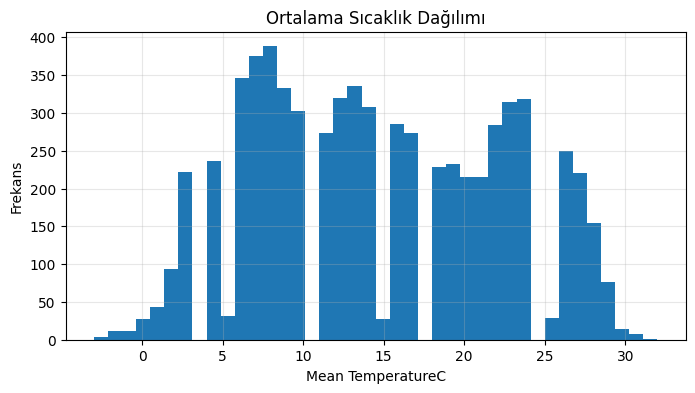

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df["Mean TemperatureC"], bins=40)
plt.xlabel("Mean TemperatureC")
plt.ylabel("Frekans")
plt.title("Ortalama Sıcaklık Dağılımı")
plt.grid(True, alpha=0.3)
plt.show()


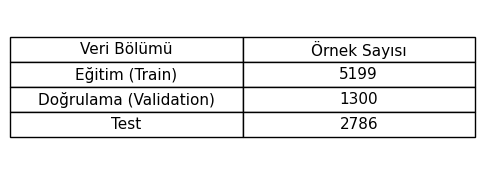

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tablo verisi
data = {
    "Veri Bölümü": ["Eğitim (Train)", "Doğrulama (Validation)", "Test"],
    "Örnek Sayısı": [5199, 1300, 2786]
}

df = pd.DataFrame(data)

# Şekil oluştur
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

# Tabloyu çiz
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

# Stil ayarları
table.scale(1, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(11)

plt.show()


In [ ]:
%whos


Variable                 Type                 Data/Info
-------------------------------------------------------
CatBoostRegressor        type                 <class 'catboost.core.CatBoostRegressor'>
DROP_COLS                list                 n=6
DecisionTreeRegressor    ABCMeta              <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
FEATURES                 list                 n=21
KNeighborsRegressor      ABCMeta              <class 'sklearn.neighbors<...>ion.KNeighborsRegressor'>
LGBMRegressor            type                 <class 'lightgbm.sklearn.LGBMRegressor'>
LinearRegression         ABCMeta              <class 'sklearn.linear_mo<...>._base.LinearRegression'>
MLPRegressor             ABCMeta              <class 'sklearn.neural_ne<...>perceptron.MLPRegressor'>
N                        int                  3
Pipeline                 ABCMeta              <class 'sklearn.pipeline.Pipeline'>
RandomForestRegressor    ABCMeta              <class 'sklearn.ensemble.<..

In [ ]:
import pandas as pd

train["CET"] = pd.to_datetime(train["CET"])
test["CET"] = pd.to_datetime(test["CET"])


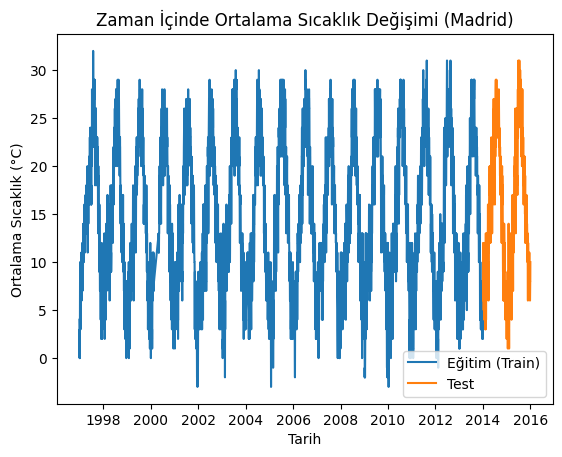

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train["CET"], train["Mean TemperatureC"], label="Eğitim (Train)")
plt.plot(test["CET"], test["Mean TemperatureC"], label="Test")
plt.xlabel("Tarih")
plt.ylabel("Ortalama Sıcaklık (°C)")
plt.title("Zaman İçinde Ortalama Sıcaklık Değişimi (Madrid)")
plt.legend()
plt.show()


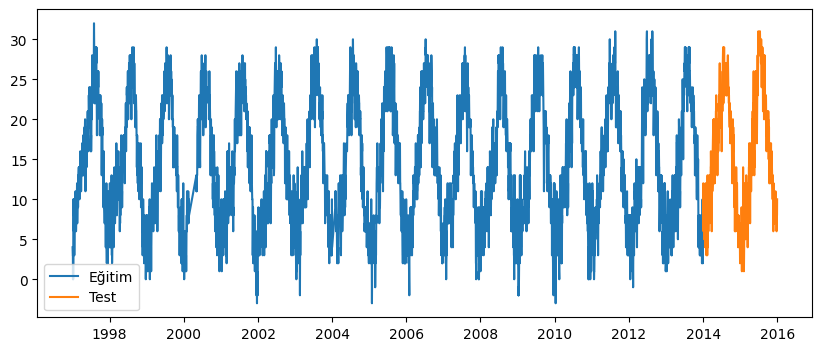

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(train["CET"], train["Mean TemperatureC"], label="Eğitim")
plt.plot(test["CET"], test["Mean TemperatureC"], label="Test")
plt.legend()
plt.show()


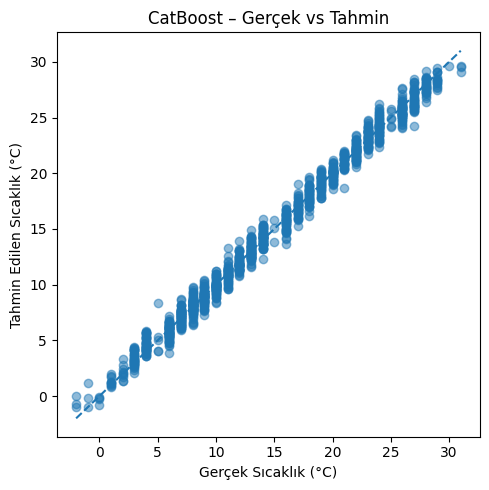

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Gerçek Sıcaklık (°C)")
plt.ylabel("Tahmin Edilen Sıcaklık (°C)")
plt.title("CatBoost – Gerçek vs Tahmin")
plt.tight_layout()
plt.show()


In [ ]:
results_df.sort_values("RMSE", ascending=False).head(1)


,Model,R2,MAE,RMSE
1,KNN,0.951032,1.284351,1.686515
